In [7]:
import pandas as pd
import matplotlib.pyplot as plt
from fredapi import Fred
from dotenv import load_dotenv
import os
# Load environment variables from .env
load_dotenv()
# Read the API key from the environment
api_key = os.getenv("fred_api_key")
if not api_key:
    raise ValueError("FRED_API_KEY not found in .env file")
fred = Fred(api_key=api_key)
# Set a unified start date for our training data
start_date = '2015-01-01'
print("FRED API Initialized Successfully.")

FRED API Initialized Successfully.


In [3]:
print("Fetching standard features...")
# 1. Fetch Inflation & Wages
cpi = fred.get_series('CPIAUCSL', observation_start=start_date)
cpi.name = 'CPI_All_Urban'

wages = fred.get_series('CES0500000003', observation_start=start_date)
wages.name = 'Nominal_Hourly_Wages'

# 2. Fetch Labor Demand (JOLTS Total Nonfarm)
jolts = fred.get_series('JTSJOL', observation_start=start_date)
jolts.name = 'JOLTS_Openings_Thousands'

print("Fetching archival revision data (Target Variable)...")
# 3. Fetch The Target Variable (Revisions) using ALFRED
# get_series_first_release() pulls the initial "vintage" number reported for that month
payems_initial = fred.get_series_first_release('PAYEMS')
payems_initial = payems_initial.loc[start_date:] # Filter to our timeframe
payems_initial.name = 'PAYEMS_Initial_Release'

# get_series() pulls the finalized, highly-revised number as it stands today
payems_final = fred.get_series('PAYEMS', observation_start=start_date)
payems_final.name = 'PAYEMS_Final_Revised'

Fetching standard features...
Fetching archival revision data (Target Variable)...


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/pandas/core/indexes/base.py:7654: FutureWarning: Dtype inference on a pandas object (Series, Index, ExtensionArray) is deprecated. The Index constructor will keep the original dtype in the future. Call `infer_objects` on the result to get the old behavior.
  return Index(sequences[0], name=names)


In [4]:
# Merge all series into a single DataFrame based on the monthly datetime index
df = pd.concat([cpi, wages, jolts, payems_initial, payems_final], axis=1)

# Drop any rows where we don't have overlapping data yet (like the most recent month)
df = df.dropna()

# --- FEATURE ENGINEERING ---

# 1. Calculate the Target Variable (Y): The Revision Magnitude
# Negative number means the initial report was too high and was revised downward
df['Revision_Delta_Thousands'] = df['PAYEMS_Final_Revised'] - df['PAYEMS_Initial_Release']

# 2. Calculate the Core Feature (X): Real Hourly Wage
# Adjusting nominal wages for inflation (Base period calculation)
# Note: This is a simplified real wage calculation to get you started
df['Real_Hourly_Wage'] = (df['Nominal_Hourly_Wages'] / df['CPI_All_Urban']) * 100

# Calculate the YoY % Change in Real Wages to spot the "Gap"
df['Real_Wage_YoY_Growth'] = df['Real_Hourly_Wage'].pct_change(periods=12) * 100

print("Data merged and engineered successfully!")

Data merged and engineered successfully!


,CPI_All_Urban,Nominal_Hourly_Wages,JOLTS_Openings_Thousands,PAYEMS_Initial_Release,PAYEMS_Final_Revised,Revision_Delta_Thousands,Real_Hourly_Wage,Real_Wage_YoY_Growth
2025-09-01,324.245,36.70,7169.0,159626.0,158548.0,-1078.0,11.318602,0.801532
2025-11-01,325.063,37.00,6846.0,159552.0,158449.0,-1103.0,11.382409,1.315316
2025-12-01,326.031,37.02,6550.0,159526.0,158432.0,-1094.0,11.354748,0.957748
2026-01-01,326.588,37.15,7240.0,158627.0,158592.0,-35.0,11.375188,1.227383
2026-02-01,327.460,37.29,6882.0,158466.0,158459.0,-7.0,11.387650,1.345323


,CPI_All_Urban,Nominal_Hourly_Wages,JOLTS_Openings_Thousands,PAYEMS_Final_Revised,Real_Hourly_Wage,Real_Wage_YoY_Growth
count,133.000000,133.000000,133.000000,133.000000,133.000000,121.000000
mean,272.424609,30.012030,7570.827068,149664.909774,10.996778,0.718343
std,30.098756,3.844579,1826.242821,6166.729889,0.275027,1.766761
min,234.747000,24.740000,4606.000000,130426.000000,10.506739,-3.393615
25%,246.626000,26.500000,6238.000000,144967.000000,10.746353,0.151669
50%,259.250000,29.510000,7162.000000,149617.000000,10.991279,0.876538
75%,302.845000,33.430000,8499.000000,155375.000000,11.236483,1.433484
max,327.460000,37.290000,12301.000000,158592.000000,11.732908,7.759101


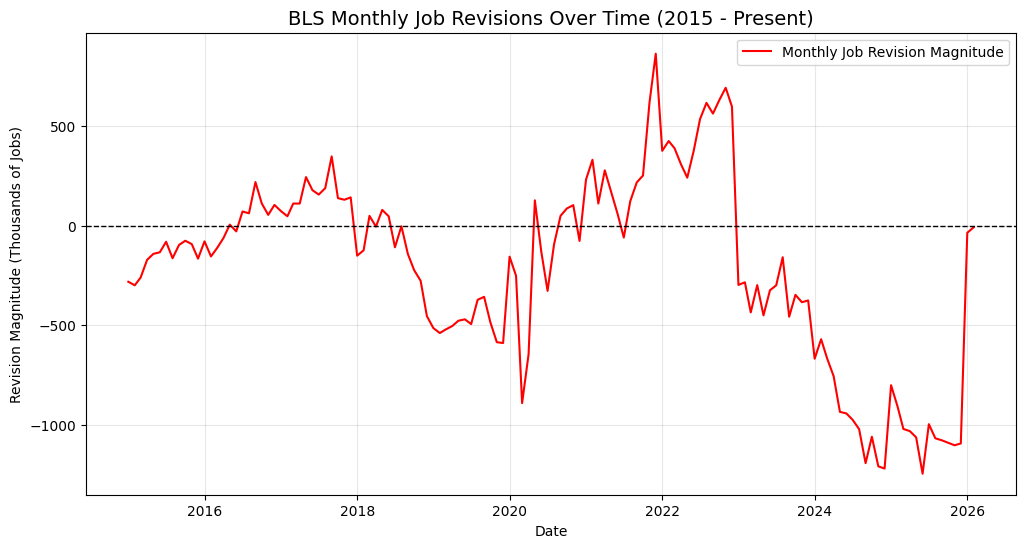

In [5]:
# 1. View the most recent 5 months of data
display(df.tail())

# 2. View general summary statistics to check for outliers
display(df.describe())

# 3. Quick Plot: Visualizing the Revisions over time
plt.figure(figsize=(12, 6))
plt.plot(df.index, df['Revision_Delta_Thousands'], color='red', label='Monthly Job Revision Magnitude')
plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.title('BLS Monthly Job Revisions Over Time (2015 - Present)', fontsize=14)
plt.ylabel('Revision Magnitude (Thousands of Jobs)')
plt.xlabel('Date')
plt.legend()
plt.grid(alpha=0.3)
plt.show()